# Compare RANS and LES Inflow

In [1]:
# Add any possible locations of amr-wind-frontend here
import sys, os
curdir = os.getcwd()
extradirs = ['../', '../../',
             '../../SANDwake3D',
             os.path.dirname(curdir),
            ]
for x in extradirs: sys.path.insert(1, x)

import numpy as np
import matplotlib.pyplot as plt

In [2]:
import numpy as np
import matplotlib
import matplotlib.pyplot as plt
import time
from scipy.integrate import solve_ivp
from scipy.optimize import fsolve
from mpl_toolkits.axes_grid1 import make_axes_locatable
#?solve_ivp

In [3]:
import pickle

def loadpickle(picklefile):
    pfile          = open(picklefile, 'rb')
    ds             = pickle.load(pfile)
    pfile.close()
    return ds

find_nearest = lambda a, a0: np.abs(np.array(a) - a0).argmin()

In [4]:
# Load RANS solution
loadpklfile = 'Phi_MedWS_LowTI.pkl'
db = loadpickle(loadpklfile)
params = db['params']
xvec   = db['xvec']
phi    = db['phi']

In [5]:
rotorD = 240
turbhh = 150

zvec=params['zm'][0,:]
yvec=params['ym'][:,0]
islice = find_nearest(yvec, 0)

In [6]:
def plotrotorlinesax(ax, zhh, rotorD, xstart, xend, **kwargs):
    ax.hlines(zhh,             xstart, xend, linewidth=1.0, **kwargs) # Plot the HH line
    ax.hlines(zhh+rotorD*0.5,  xstart, xend, linewidth=0.5, **kwargs) # Plot the HH line
    ax.hlines(zhh-rotorD*0.5,  xstart, xend, linewidth=0.5, **kwargs) # Plot the HH line   

Text(0.5, 0, 'TI [-]')

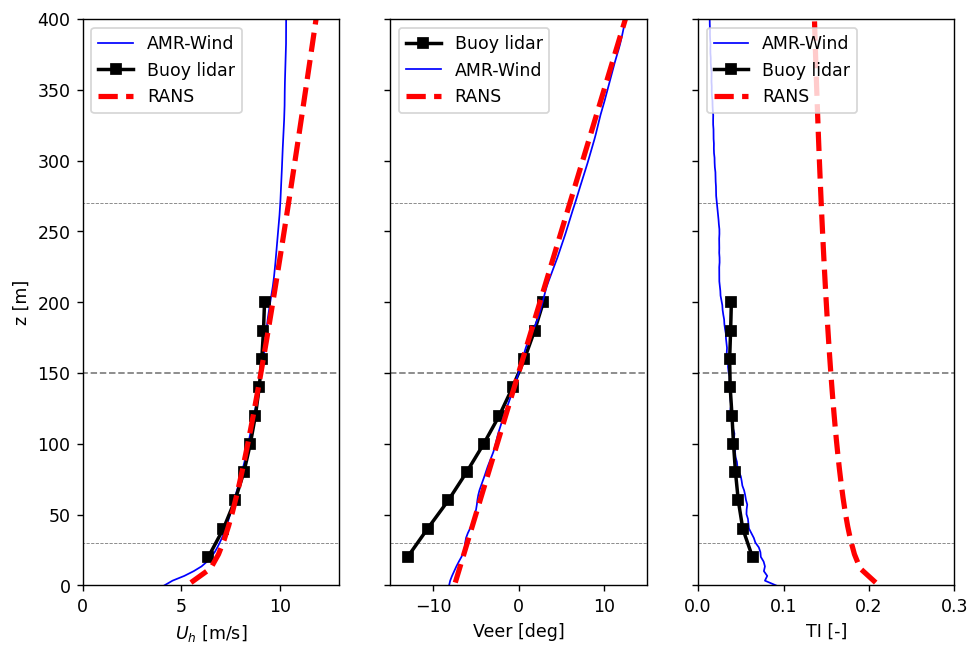

In [7]:
lidardir='./'

# Plot wind speed
WS_z     = np.loadtxt(lidardir+'/MedWS_LowTI_heights.dat')
WS_lidar = np.loadtxt(lidardir+'/MedWS_LowTI_WSmean.dat')
WDC_lidar = np.loadtxt(lidardir+'/MedWS_LowTI_WDCmean.dat')
TI_lidar = np.loadtxt(lidardir+'/MedWS_LowTI_TImean.dat')
AMRdat   = np.loadtxt(lidardir+'/AMRWIND_MedWS_LowTI_metmast.dat')

AMR_WDzhh = np.interp(turbhh, AMRdat[:,0], AMRdat[:,4])

#iRANS=-1
iRANS=0
fig, axs = plt.subplots(1,3, figsize=(9,6), dpi=125, sharey=True)

# --- plot velocity ---
ax=axs[0]
# Plot AMR-Wind data
ax.plot(AMRdat[:,1], AMRdat[:,0], 'b-', label='AMR-Wind', lw=1)
# Plot lidar data
ax.plot(WS_lidar,WS_z, 'k-', marker='s', label='Buoy lidar', lw=2)
# Plot RANS data
Uh = np.sqrt(phi['u'][iRANS,islice,:]**2 + phi['v'][iRANS,islice,:]**2)
ax.plot(Uh, zvec, 'r--', lw=3, label='RANS')

# --- plot veer ---
ax=axs[1]
ax.plot(WDC_lidar, WS_z, 'k-s',  lw=2, label='Buoy lidar')
ax.plot(AMRdat[:,4]-AMR_WDzhh, AMRdat[:,0], 'b-', label='AMR-Wind', lw=1)

WD_RANS = np.arctan2(phi['v'][iRANS,islice,:], phi['u'][iRANS,islice,:])*180/np.pi
ax.plot(WD_RANS, zvec, 'r--', lw=3, label='RANS')
ax.set_xlim([-15, 15])
ax.set_xlabel('Veer [deg]')
              
# --- plot TI ---
ax=axs[2]
# Plot AMR-Wind data
ax.plot(AMRdat[:,7], AMRdat[:,0], 'b-', label='AMR-Wind', lw=1)
# Plot lidar data
ax.plot(TI_lidar,WS_z, 'k-', marker='s', label='Buoy lidar', lw=2)
# Plot RANS
# TKE = 0.5*(uu + vv + ww)  = 1.5*(uu)
# uu = 2/3*TKE
TI_RANS = np.sqrt((4.0/3.0)*phi['k'][iRANS,islice,:]/phi['u'][iRANS,islice,:])
ax.plot(TI_RANS, zvec, 'r--', lw=3, label='RANS')


for ax in axs:
    ax.set_ylim([0,400])
    ax.legend(loc='upper left')
    # Plot the turbine dimensions
    plotrotorlinesax(ax, turbhh, rotorD, -15, 20, linestyles='dashed', color='gray',)
    
ax=axs[0]
ax.set_xlim([0, 13])
ax.set_xlabel('$U_h$ [m/s]')
ax.set_ylabel('z [m]')

ax=axs[2]
ax.set_xlim([0, 0.3])
ax.set_xlabel('TI [-]')
